In [1]:
from transformers import set_seed, DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
import random
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import nlpaug.augmenter.word as naw
import pandas as pd
import nltk

# Set seed
seed = 42
set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

## Load the split dataset

In [2]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ziqianwei/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/ziqianwei/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/ziqianwei/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
# Verify the download location
print("NLTK data paths:", nltk.data.path)

NLTK data paths: ['/Users/ziqianwei/nltk_data', '/opt/homebrew/Caskroom/miniforge/base/nltk_data', '/opt/homebrew/Caskroom/miniforge/base/share/nltk_data', '/opt/homebrew/Caskroom/miniforge/base/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


In [4]:

splits = {
    'train': 'split/train-00000-of-00001.parquet',
    'validation': 'split/validation-00000-of-00001.parquet',
    'test': 'split/test-00000-of-00001.parquet'
}

df_train = pd.read_parquet("hf://datasets/dair-ai/emotion/" + splits["train"])
df_val = pd.read_parquet("hf://datasets/dair-ai/emotion/" + splits["validation"])
df_test = pd.read_parquet("hf://datasets/dair-ai/emotion/" + splits["test"])


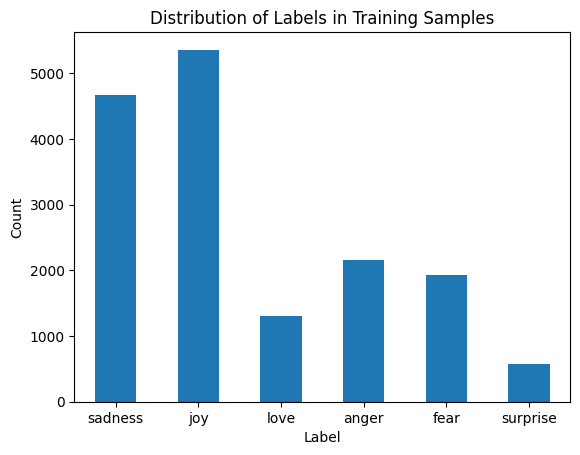

In [5]:
import matplotlib.pyplot as plt
ll = ["sadness", "joy", "love", "anger", "fear", "surprise"]

label_counts = df_train["label"].value_counts().sort_index()
label_counts.plot(kind="bar")
plt.xticks(ticks=range(len(ll)), labels=ll, rotation = 0)  # custom labels
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels in Training Samples")
plt.show()

## Weighted Class and Data Augmentation 

In [6]:
import nltk
from nltk.tag.perceptron import PerceptronTagger

# Define a custom _get_tagger function that ignores the language suffix for English
def my_get_tagger(lang="eng"):
    if lang == "eng":
        return PerceptronTagger()  # Load default tagger (from averaged_perceptron_tagger)
    else:
        # Fall back to the original behavior for other languages
        from nltk.tag import PerceptronTagger as OrigTagger
        return OrigTagger(lang=lang)

# Monkey patch nltk's internal function
nltk.tag._get_tagger = my_get_tagger


In [7]:

# Initialize synonym augmenter
aug = naw.SynonymAug(aug_src='wordnet')

# Safe augmentation wrapper
def augment_text(text, n=1):
    try:
        result = aug.augment(text, n=n)
        return result[0] if isinstance(result, list) and len(result) > 0 else text
    except Exception as e:
        print(f"[AUG FAIL] '{text[:40]}...' → {str(e)}")
        return text  # fallback to original

# Augment minority samples
def augment_minority_samples(texts, labels, minority_classes=[2, 4, 5]):
    new_texts, new_labels = [], []
    for text, label in zip(texts, labels):
        if label in minority_classes:
            augmented = augment_text(text)
            new_texts.append(augmented)
            new_labels.append(label)
    return new_texts, new_labels

# Combine original and augmented
texts = df_train['text'].tolist()
labels = df_train['label'].tolist()
aug_texts, aug_labels = augment_minority_samples(texts, labels)
all_texts = texts + aug_texts
all_labels = labels + aug_labels


In [8]:
# Class weights

y_train = df_train['label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)


In [9]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In [10]:
class_weights

array([0.57151022, 0.49732687, 2.04498978, 1.23513973, 1.37669936,
       4.66200466])

## Check imbalance handling results

In [11]:
import pandas as pd
from collections import Counter

# Original counts
original_counts = Counter(df_train['label'])

# Augmented counts
augmented_counts = Counter(aug_labels)

# Combined counts
combined_counts = Counter(all_labels)

# Create comparison table
count_df = pd.DataFrame({
    'Original': original_counts,
    'Augmented': augmented_counts,
    'Combined': combined_counts
}).sort_index()

print("Sample Counts per Label:")
print(count_df)

Sample Counts per Label:
   Original  Augmented  Combined
0      4666        NaN      4666
1      5362        NaN      5362
2      1304     1304.0      2608
3      2159        NaN      2159
4      1937     1937.0      3874
5       572      572.0      1144


## Saving aumented dataframe

In [12]:

# Create DataFrames
aug_df = pd.DataFrame({'text': aug_texts, 'label': aug_labels})
combined_df = pd.DataFrame({'text': all_texts, 'label': all_labels})

# Save
#aug_df.to_parquet('augmented_data.parquet', engine='pyarrow')
#combined_df.to_parquet('combined_data.parquet', engine='pyarrow')

## Finetuning model on augmented data

In [13]:
all_texts = combined_df['text'].tolist()
all_labels = combined_df['label'].tolist()

# Dataset object
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)
        
# Tokenize
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
encodings = tokenizer(all_texts, truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(df_val['text'].tolist(), truncation=True, padding=True)

# Create validation labels list
val_labels = df_val['label'].tolist()

eval_dataset = EmotionDataset(val_encodings, val_labels)



train_dataset = EmotionDataset(encodings, all_labels)

# Model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=6,
    id2label={0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
)

# TrainingArguments
training_args = TrainingArguments(
    output_dir="models/",
    per_device_train_batch_size=32,  
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="logs/",
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    num_train_epochs=2
)

# Custom Trainer for weighted loss
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Get labels from inputs
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Apply class weights if provided
        if self.class_weights is not None:
            device = model.device
            weights = torch.tensor(self.class_weights, dtype=torch.float32).to(device)  # 先转Tensor，再to(device)
            loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        else:
            loss_fct = torch.nn.CrossEntropyLoss()
            
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# Evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "f1": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds)
    }

trainer = WeightedTrainer(
    model=model,
    class_weights=class_weights,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,  # Or use validation set if tokenized
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/86/f69dgq8n44972fnfy7r447yc0000gn/T/ipykernel_4114/3542149017.py:58: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [14]:
trainer.train()
#trainer.save_model("models/final_model")
#tokenizer.save_pretrained("models/final_model")

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.237900,0.199466,0.898646,0.922500
2,0.142700,0.181002,0.907388,0.931500


TrainOutput(global_step=1240, training_loss=0.3234657956707862, metrics={'train_runtime': 841.233, 'train_samples_per_second': 47.105, 'train_steps_per_second': 1.474, 'total_flos': 656190947990016.0, 'train_loss': 0.3234657956707862, 'epoch': 2.0})

In [15]:
from sklearn.metrics import classification_report

# Get predictions on validation set
predictions = trainer.predict(eval_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Print classification report
print(classification_report(labels, preds, target_names=model.config.id2label.values()))

              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       550
         joy       0.97      0.93      0.95       704
        love       0.82      0.92      0.87       178
       anger       0.95      0.93      0.94       275
        fear       0.87      0.89      0.88       212
    surprise       0.79      0.90      0.84        81

    accuracy                           0.93      2000
   macro avg       0.89      0.92      0.91      2000
weighted avg       0.93      0.93      0.93      2000



## Evaluating on Test set

In [16]:
# Tokenize test set
test_encodings = tokenizer(df_test['text'].tolist(), truncation=True, padding=True)
test_labels = df_test['label'].tolist()
test_dataset = EmotionDataset(test_encodings, test_labels)

# Evaluate
test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=1)

print("Test Set Performance:")
print(classification_report(test_labels, test_preds, target_names=model.config.id2label.values()))

Test Set Performance:
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.97      0.92      0.95       695
        love       0.77      0.92      0.84       159
       anger       0.93      0.92      0.92       275
        fear       0.90      0.87      0.88       224
    surprise       0.68      0.92      0.78        66

    accuracy                           0.93      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.93      0.93      0.93      2000



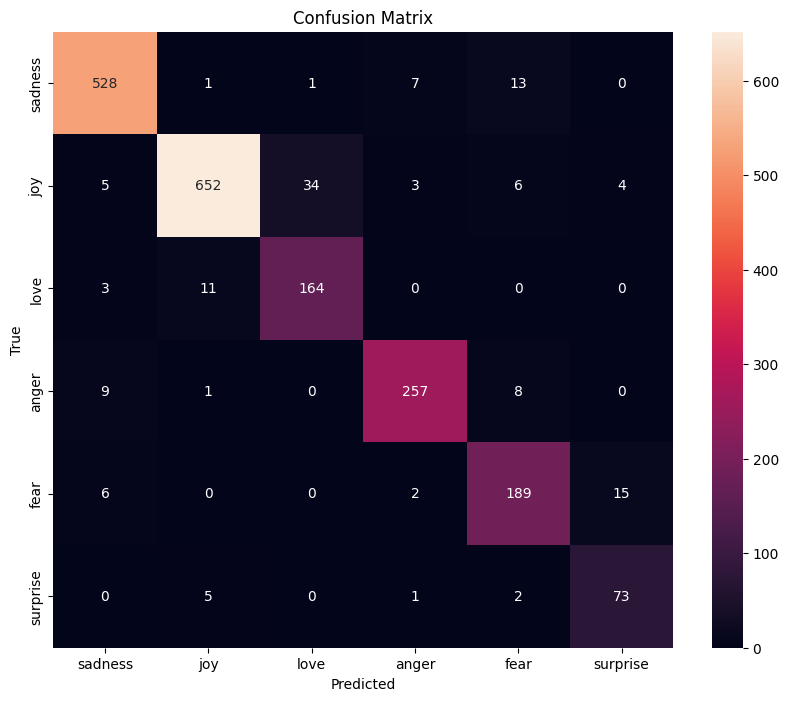

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.config.id2label.values(), yticklabels=model.config.id2label.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Vanilla Logistic

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# Prepare data
X_train = df_train['text'].tolist()
y_train = df_train['label'].tolist()

X_val = df_val['text'].tolist()
y_val = df_val['label'].tolist()

X_test = df_test['text'].tolist()
y_test = df_test['label'].tolist()

# TF-IDF + Logistic Regression pipeline
baseline_model = make_pipeline(
    TfidfVectorizer(max_features=5000),  # Limit features to avoid overfitting
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

# Train
baseline_model.fit(X_train, y_train)

# Evaluate on validation set
y_test_pred = baseline_model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91       581
           1       0.94      0.87      0.90       695
           2       0.67      0.91      0.77       159
           3       0.86      0.92      0.89       275
           4       0.88      0.84      0.86       224
           5       0.59      0.86      0.70        66

    accuracy                           0.88      2000
   macro avg       0.81      0.88      0.84      2000
weighted avg       0.89      0.88      0.88      2000



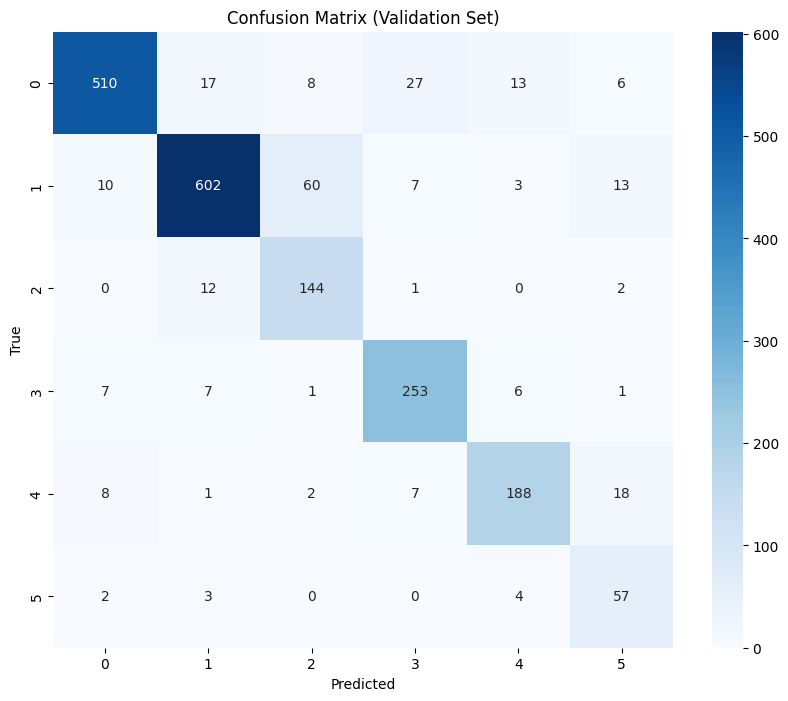

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Get class labels
class_names = np.unique(y_test)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation Set)")
plt.show()
